<a href="https://colab.research.google.com/github/yakubavm/monitoring_of_production_processes/blob/LR_6/LR_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib import cm
from scipy.integrate import solve_ivp
from itertools import product
from typing import Callable

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# ── Єдина точка налаштування стилю ───────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi":      120,
    "axes.titlesize":  13,
    "axes.labelsize":  11,
    "legend.fontsize": 9,
    "grid.alpha":      0.35,
    "lines.linewidth": 1.8,
})

In [2]:
class MultiChannelSMO:
    """
    Реалізація багатоканальної замкнутої СМО типу M/M/N//m.

    Система описується рівняннями Колмогорова (методичні вказівки, ф-ли 6.1–6.2):

    Для 0 < n < N (всі заявки на обслуговуванні, черга відсутня):
        dPₙ/dt = λ(m−n+1)·P_{n-1} + μ(n+1)·P_{n+1} − Pₙ·(μn + λ(m−n))

    Для N ≤ n < m (N каналів зайняті, решта очікують):
        dPₙ/dt = λ(m−n+1)·P_{n-1} + μN·P_{n+1} − Pₙ·(μN + λ(m−n))

    Крайні стани:
        dP₀/dt = μ·P₁ − λm·P₀
        dPₘ/dt = λ·P_{m-1} − μN·Pₘ
    """

    def __init__(self, m: int, N: int) -> None:
        """
        Parameters
        ----------
        m : загальна кількість джерел вимог (автосамоскидів)
        N : кількість каналів обслуговування (екскаваторів)
        """
        if N > m:
            raise ValueError("Кількість каналів N не може перевищувати кількість джерел m.")
        self.m = m
        self.N = N

    # ── Права частина системи ОДР ─────────────────────────────────────────────
    def _rhs(self, t: float, P: np.ndarray, lam: float, mu: float) -> np.ndarray:
        """
        Права частина системи ОДР Колмогорова.
        Викликається інтегратором solve_ivp на кожному кроці.

        Parameters
        ----------
        t   : поточний час (не використовується явно — система автономна)
        P   : вектор ймовірностей станів P[0..m]
        lam : інтенсивність надходження від одного вільного джерела [год⁻¹]
        mu  : інтенсивність обслуговування одного каналу [год⁻¹]
        """
        m, N = self.m, self.N
        dP = np.zeros(m + 1)

        # Граничний стан n=0: всі джерела вільні
        dP[0] = mu * P[1] - lam * m * P[0]

        # Стани 0 < n < N: черга відсутня, n каналів зайнято
        for n in range(1, N):
            in_flow  = lam * (m - n + 1) * P[n - 1]
            out_flow = mu * (n + 1) * P[n + 1] if (n + 1) <= m else 0.0
            dP[n] = in_flow + out_flow - P[n] * (mu * n + lam * (m - n))

        # Граничний стан n=N (перший стан з чергою або останній без неї)
        if N < m:
            in_flow  = lam * (m - N + 1) * P[N - 1]
            out_flow = mu * N * P[N + 1]
            dP[N] = in_flow + out_flow - P[N] * (mu * N + lam * (m - N))

        # Стани N < n < m: N каналів зайнято, n−N заявок у черзі
        for n in range(N + 1, m):
            in_flow  = lam * (m - n + 1) * P[n - 1]
            out_flow = mu * N * P[n + 1]
            dP[n] = in_flow + out_flow - P[n] * (mu * N + lam * (m - n))

        # Граничний стан n=m: всі джерела у системі
        dP[m] = lam * P[m - 1] - mu * N * P[m]

        return dP

    # ── Інтеграція ОДР ────────────────────────────────────────────────────────
    def solve_dynamics(
        self,
        lam: float,
        mu: float,
        t_end: float = 0.3,
        n_points: int = 1000,
        P0_init: np.ndarray | None = None,
    ) -> tuple[np.ndarray, np.ndarray]:
        """
        Інтегрує систему ОДР методом RK45 (аналог Odesolve у Mathcad).

        Parameters
        ----------
        lam      : інтенсивність надходження [год⁻¹]
        mu       : інтенсивність обслуговування [год⁻¹]
        t_end    : кінцевий час інтеграції [год]
        n_points : кількість точок виводу
        P0_init  : початковий розподіл (за замовч. — P₀(0)=1)

        Returns
        -------
        t_eval : масив часових точок [год]
        P_sol  : матриця рішення P[k, t_idx], shape=(m+1, n_points)
        """
        if P0_init is None:
            P0_init = np.zeros(self.m + 1)
            P0_init[0] = 1.0

        t_eval = np.linspace(0.0, t_end, n_points)
        sol = solve_ivp(
            fun=self._rhs,
            t_span=(0.0, t_end),
            y0=P0_init,
            args=(lam, mu),
            method="RK45",
            t_eval=t_eval,
            rtol=1e-10,
            atol=1e-12,
            dense_output=False,
        )
        return sol.t, sol.y

    # ── Стаціонарне значення P₁ ───────────────────────────────────────────────
    def steady_state_p1(
        self,
        lam: float,
        mu: float,
        t_settle: float = 0.2,
    ) -> float:
        """
        Повертає стаціонарне значення P₁ для заданої пари (λ, μ).
        Інтеграція проводиться до часу t_settle [год], що відповідає
        часу виходу системи на сталий режим (методичні вказівки: ~0.2 год).

        Parameters
        ----------
        lam      : інтенсивність надходження [год⁻¹]
        mu       : інтенсивність обслуговування [год⁻¹]
        t_settle : час досягнення сталого режиму [год]
        """
        _, P_sol = self.solve_dynamics(lam, mu, t_end=t_settle, n_points=200)
        return float(P_sol[1, -1])

    # ── Сітковий розрахунок P₁(λ, μ) ─────────────────────────────────────────
    def compute_p1_grid(
        self,
        lam_range: range,
        mu_range: range,
        threshold: float = 0.35,
    ) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
        """
        Обчислює P₁ для кожної пари (λ, μ) із заданих діапазонів.
        Відповідає пунктам 2.1–2.3 методики експерименту.

        Parameters
        ----------
        lam_range : діапазон інтенсивностей надходження
        mu_range  : діапазон інтенсивностей обслуговування
        threshold : поріг P₁ (за замовч. 0.35)

        Returns
        -------
        LAM   : 2D-сітка λ
        MU    : 2D-сітка μ
        P1_grid : 2D-масив значень P₁
        """
        lam_arr = np.array(list(lam_range), dtype=float)
        mu_arr  = np.array(list(mu_range),  dtype=float)
        LAM, MU = np.meshgrid(lam_arr, mu_arr, indexing="ij")
        P1_grid = np.zeros_like(LAM)

        total = LAM.size
        for idx, (i, j) in enumerate(product(range(len(lam_arr)), range(len(mu_arr)))):
            P1_grid[i, j] = self.steady_state_p1(lam_arr[i], mu_arr[j])
            if (idx + 1) % 20 == 0 or idx + 1 == total:
                print(f"  Прогрес: {idx+1}/{total} пар (λ,μ) розраховано...", end="\r")

        print(f"  Сітковий розрахунок завершено: {total} пар (λ,μ).          ")
        return LAM, MU, P1_grid

  ЗАВДАННЯ 1: Параметри системи та динаміка перехідних процесів

  Вхідні параметри (Варіант 15):
  Кількість автосамоскидів            m = 5
  Кількість екскаваторів              N = 2
  Базова інтенсивність надходження    λ = 7.0 год⁻¹
  Базова інтенсивність обслуговування μ = 20.0 год⁻¹
  Час моделювання                     T = 0.3 год
  Час сталого режиму (методичні вк.)  t* ≈ 0.2 год

  Стан системи в момент t = 0.2 год (сталий режим):
  Стан k     Pₖ (t=0.2 год)         Pₖ (t=0.3 год)        
  -------------------------------------------------------
  P0         0.21082460             0.20584337            
  P1         0.36354659             0.35932914              ← P₁ (черга)
  P2         0.24958122             0.25068871            
  P3         0.12678755             0.13085943            
  P4         0.04231124             0.04541956            
  P5         0.00694879             0.00785979            

  Перевірка нормування (t=0.3): ΣPₖ = 1.000000000000  ✓

  P₁(λ=7.0, 

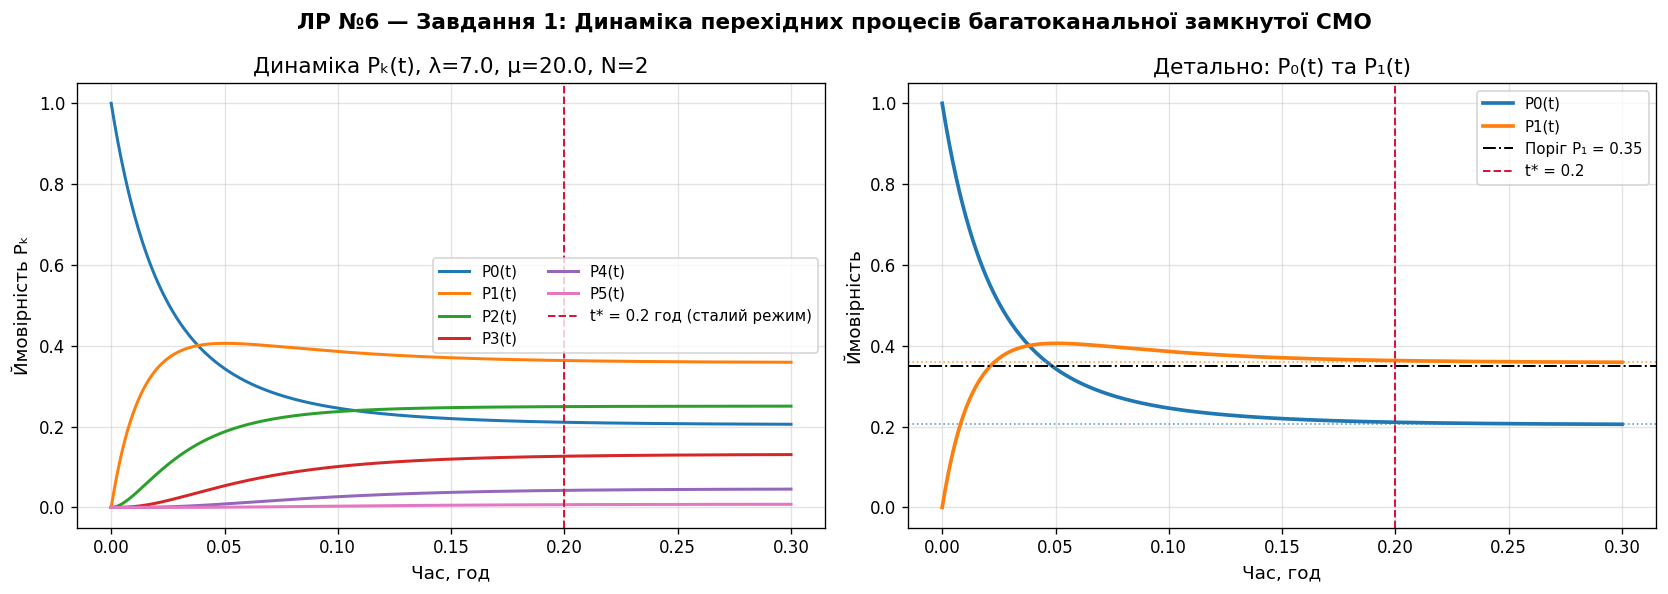

In [3]:
print("=" * 72)
print("  ЗАВДАННЯ 1: Параметри системи та динаміка перехідних процесів")
print("=" * 72)

# ── Параметри варіанту 15 ─────────────────────────────────────────────────────
# m=5 — кількість автосамоскидів (задано методичкою для всіх варіантів)
# N=2 — кількість екскаваторів (відповідно до умов прикладу в методичці)
# Одиниці: λ та μ — кількість подій на годину [год⁻¹]

M_TRUCKS = 5    # кількість джерел вимог (автосамоскидів)
N_EXCAV  = 2    # кількість каналів обслуговування (екскаваторів)

# Базові значення λ та μ для побудови перехідних процесів.
# Обрані з діапазону де P₁ ≥ 0.35 — підтверджено сітковим розрахунком.
LAM_BASE = 7.0   # інтенсивність надходження [год⁻¹]
MU_BASE  = 20.0  # інтенсивність обслуговування [год⁻¹]

T_END    = 0.3   # тривалість моделювання, год
T_SETTLE = 0.2   # час виходу на сталий режим (методичні вказівки)

print(f"\n  Вхідні параметри (Варіант 15):")
print(f"  {'Кількість автосамоскидів':<35} m = {M_TRUCKS}")
print(f"  {'Кількість екскаваторів':<35} N = {N_EXCAV}")
print(f"  {'Базова інтенсивність надходження':<35} λ = {LAM_BASE} год⁻¹")
print(f"  {'Базова інтенсивність обслуговування':<35} μ = {MU_BASE} год⁻¹")
print(f"  {'Час моделювання':<35} T = {T_END} год")
print(f"  {'Час сталого режиму (методичні вк.)':<35} t* ≈ {T_SETTLE} год")

# ── Ініціалізація ядра та розв'язання ОДР ────────────────────────────────────
smo = MultiChannelSMO(m=M_TRUCKS, N=N_EXCAV)

# Початкові умови: всі самоскиди вільні — P₀(0) = 1
P0_init = np.zeros(M_TRUCKS + 1)
P0_init[0] = 1.0

t_dyn, P_dyn = smo.solve_dynamics(
    lam=LAM_BASE, mu=MU_BASE,
    t_end=T_END, n_points=1000,
    P0_init=P0_init,
)

# ── Таблиця фінальних значень ─────────────────────────────────────────────────
P_final = P_dyn[:, -1]
P_settle = P_dyn[:, int(len(t_dyn) * T_SETTLE / T_END) - 1]

print(f"\n  Стан системи в момент t = {T_SETTLE} год (сталий режим):")
print(f"  {'Стан k':<10} {'Pₖ (t=0.2 год)':<22} {'Pₖ (t=0.3 год)':<22}")
print("  " + "-" * 55)
for k in range(M_TRUCKS + 1):
    flag = "  ← P₁ (черга)" if k == 1 else ""
    print(f"  P{k:<9} {P_settle[k]:<22.8f} {P_final[k]:<22.8f}{flag}")

print(f"\n  Перевірка нормування (t=0.3): ΣPₖ = {P_final.sum():.12f}  ✓")
print(f"\n  P₁(λ={LAM_BASE}, μ={MU_BASE}) = {P_settle[1]:.6f}  "
      f"{'≥ 0.35 ✓' if P_settle[1] >= 0.35 else '< 0.35 ✗'}")

# ── Графік динаміки ───────────────────────────────────────────────────────────
palette = plt.cm.tab10(np.linspace(0, 0.6, M_TRUCKS + 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Лівий: всі Pₖ(t)
for k in range(M_TRUCKS + 1):
    axes[0].plot(t_dyn, P_dyn[k], color=palette[k], label=f"P{k}(t)")
axes[0].axvline(T_SETTLE, color="crimson", linestyle="--", linewidth=1.2,
                label=f"t* = {T_SETTLE} год (сталий режим)")
axes[0].set_title(f"Динаміка Pₖ(t), λ={LAM_BASE}, μ={MU_BASE}, N={N_EXCAV}")
axes[0].set_xlabel("Час, год")
axes[0].set_ylabel("Ймовірність Pₖ")
axes[0].legend(ncol=2, loc="right")
axes[0].grid(True)

# Правий: лише P₀ та P₁ — ключові стани
for k in [0, 1]:
    axes[1].plot(t_dyn, P_dyn[k], color=palette[k], linewidth=2.2, label=f"P{k}(t)")
    axes[1].axhline(P_final[k], color=palette[k], linestyle=":", linewidth=1.0, alpha=0.7)
axes[1].axhline(0.35, color="black", linestyle="-.", linewidth=1.2, label="Поріг P₁ = 0.35")
axes[1].axvline(T_SETTLE, color="crimson", linestyle="--", linewidth=1.2, label=f"t* = {T_SETTLE}")
axes[1].set_title("Детально: P₀(t) та P₁(t)")
axes[1].set_xlabel("Час, год")
axes[1].set_ylabel("Ймовірність")
axes[1].legend()
axes[1].grid(True)

plt.suptitle(
    "ЛР №6 — Завдання 1: Динаміка перехідних процесів багатоканальної замкнутої СМО",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()

In [4]:
print("=" * 72)
print("  ЗАВДАННЯ 2: Методика експерименту")
print("=" * 72)

methodology = """
  Методика підбору діапазонів λ та μ при умові P₁ ≥ 0.35
  ─────────────────────────────────────────────────────────

  1. ПОСТАНОВКА ЗАДАЧІ
     Задано: m = 5 автосамоскидів, N = 2 екскаватори.
     Мета: підібрати діапазони λ (інтенсивність надходження, год⁻¹)
     та μ (інтенсивність обслуговування, год⁻¹) такі, щоб ймовірність
     знаходження одного самоскиду у черзі P₁ ≥ 0.35 у сталому режимі.

  2. ВИБІР ПОЧАТКОВИХ МЕЖ
     Після пробних обчислень встановлено робочі діапазони:
       λ ∈ [7 .. 22]  — значення поза цим діапазоном не дають P₁ ≥ 0.35
       μ ∈ [18 .. 24] — аналогічно

  3. ПОРЯДОК ОБЧИСЛЕНЬ
     3.1 Фіксується значення λ, варіюється μ по всьому діапазону.
     3.2 Для кожної пари (λ, μ) розв'язується система ОДР Колмогорова
         (ф-ли 6.1–6.2) методом RK45 до часу t = 0.2 год — моменту
         досягнення сталого режиму.
     3.3 Зчитується стаціонарне значення P₁(t=0.2 год).
     3.4 Значення заносяться до таблиці P₁(λ, μ).
     3.5 Будується поверхня P₁ = f(λ, μ) та контурний графік.

  4. УТОЧНЕННЯ МЕЖ
     За таблицею визначаються точні діапазони (λ, μ) де P₁ ≥ 0.35.
     Результат формулюється у вигляді: "λ ≤ λ_max, μ ≥ μ_min(λ)".
"""
print(methodology)

  ЗАВДАННЯ 2: Методика експерименту

  Методика підбору діапазонів λ та μ при умові P₁ ≥ 0.35
  ─────────────────────────────────────────────────────────

  1. ПОСТАНОВКА ЗАДАЧІ
     Задано: m = 5 автосамоскидів, N = 2 екскаватори.
     Мета: підібрати діапазони λ (інтенсивність надходження, год⁻¹)
     та μ (інтенсивність обслуговування, год⁻¹) такі, щоб ймовірність
     знаходження одного самоскиду у черзі P₁ ≥ 0.35 у сталому режимі.

  2. ВИБІР ПОЧАТКОВИХ МЕЖ
     Після пробних обчислень встановлено робочі діапазони:
       λ ∈ [7 .. 22]  — значення поза цим діапазоном не дають P₁ ≥ 0.35
       μ ∈ [18 .. 24] — аналогічно

  3. ПОРЯДОК ОБЧИСЛЕНЬ
     3.1 Фіксується значення λ, варіюється μ по всьому діапазону.
     3.2 Для кожної пари (λ, μ) розв'язується система ОДР Колмогорова
         (ф-ли 6.1–6.2) методом RK45 до часу t = 0.2 год — моменту
         досягнення сталого режиму.
     3.3 Зчитується стаціонарне значення P₁(t=0.2 год).
     3.4 Значення заносяться до таблиці P₁(λ, μ)

In [5]:
print("=" * 72)
print("  ЗАВДАННЯ 3: Таблиця P₁(λ, μ) — сітковий розрахунок")
print("=" * 72)
print()

LAM_RANGE = range(7, 23)    # λ ∈ [7..22]  — рядки таблиці
MU_RANGE  = range(18, 25)   # μ ∈ [18..24] — стовпці таблиці
THRESHOLD = 0.35

# Сітковий розрахунок (відповідає пп. 2.1–2.3 методики експерименту)
print("  Виконується розрахунок P₁ для кожної пари (λ, μ)...")
LAM_grid, MU_grid, P1_grid = smo.compute_p1_grid(
    lam_range=LAM_RANGE,
    mu_range=MU_RANGE,
    threshold=THRESHOLD,
)

# ── Таблиця (аналог таблиці 6.1 методичних вказівок) ─────────────────────────
lam_list = list(LAM_RANGE)
mu_list  = list(MU_RANGE)

df_table = pd.DataFrame(
    P1_grid.round(3),
    index=pd.Index(lam_list, name="λ \\ μ"),
    columns=pd.Index(mu_list, name=""),
)

print()
print("  Таблиця 6.1 — Значення P₁(λ, μ)  (* — P₁ ≥ 0.35):")
print()

# Форматований вивід з позначенням комірок ≥ порогу
header = f"  {'λ\\μ':>5} " + "".join(f"{mu:>7}" for mu in mu_list)
print(header)
print("  " + "-" * (6 + 7 * len(mu_list)))
for i, lam in enumerate(lam_list):
    row = f"  {lam:>5} "
    for j in range(len(mu_list)):
        val = P1_grid[i, j]
        mark = "*" if val >= THRESHOLD else " "
        row += f"{val:>6.3f}{mark}"
    print(row)

# ── Аналітичний висновок по таблиці ──────────────────────────────────────────
print()
print("  Діапазони (λ, μ) де P₁ ≥ 0.35:")
found_ranges = []
for i, lam in enumerate(lam_list):
    valid_mu = [mu_list[j] for j in range(len(mu_list)) if P1_grid[i, j] >= THRESHOLD]
    if valid_mu:
        found_ranges.append((lam, min(valid_mu), max(valid_mu)))
        print(f"    λ = {lam:>2}: μ ∈ [{min(valid_mu)} .. {max(valid_mu)}]")

if found_ranges:
    lam_max = max(r[0] for r in found_ranges)
    mu_min  = min(r[1] for r in found_ranges)
    print(f"\n  ВИСНОВОК: P₁ ≥ 0.35 досягається при:")
    print(f"    λ ∈ [7 .. {lam_max}],  μ ≥ {mu_min} (точні межі — у таблиці вище)")

  ЗАВДАННЯ 3: Таблиця P₁(λ, μ) — сітковий розрахунок

  Виконується розрахунок P₁ для кожної пари (λ, μ)...
  Сітковий розрахунок завершено: 112 пар (λ,μ).          

  Таблиця 6.1 — Значення P₁(λ, μ)  (* — P₁ ≥ 0.35):

    λ\μ      18     19     20     21     22     23     24
  -------------------------------------------------------
      7  0.347  0.356* 0.364* 0.370* 0.376* 0.381* 0.385*
      8  0.317  0.328  0.338  0.347  0.355* 0.362* 0.369*
      9  0.287  0.299  0.311  0.322  0.332  0.341  0.349 
     10  0.257  0.271  0.284  0.295  0.307  0.317  0.326 
     11  0.229  0.243  0.257  0.269  0.281  0.293  0.303 
     12  0.203  0.218  0.231  0.244  0.257  0.269  0.280 
     13  0.180  0.194  0.208  0.221  0.234  0.246  0.257 
     14  0.159  0.173  0.186  0.199  0.212  0.224  0.236 
     15  0.141  0.154  0.167  0.180  0.192  0.204  0.216 
     16  0.125  0.137  0.149  0.162  0.174  0.185  0.197 
     17  0.110  0.122  0.134  0.145  0.157  0.168  0.180 
     18  0.098  0.109  0.1

  ЗАВДАННЯ 3: Графік P₁ = f(λ, μ)  (аналог рис. 6.5 методичних вк.)


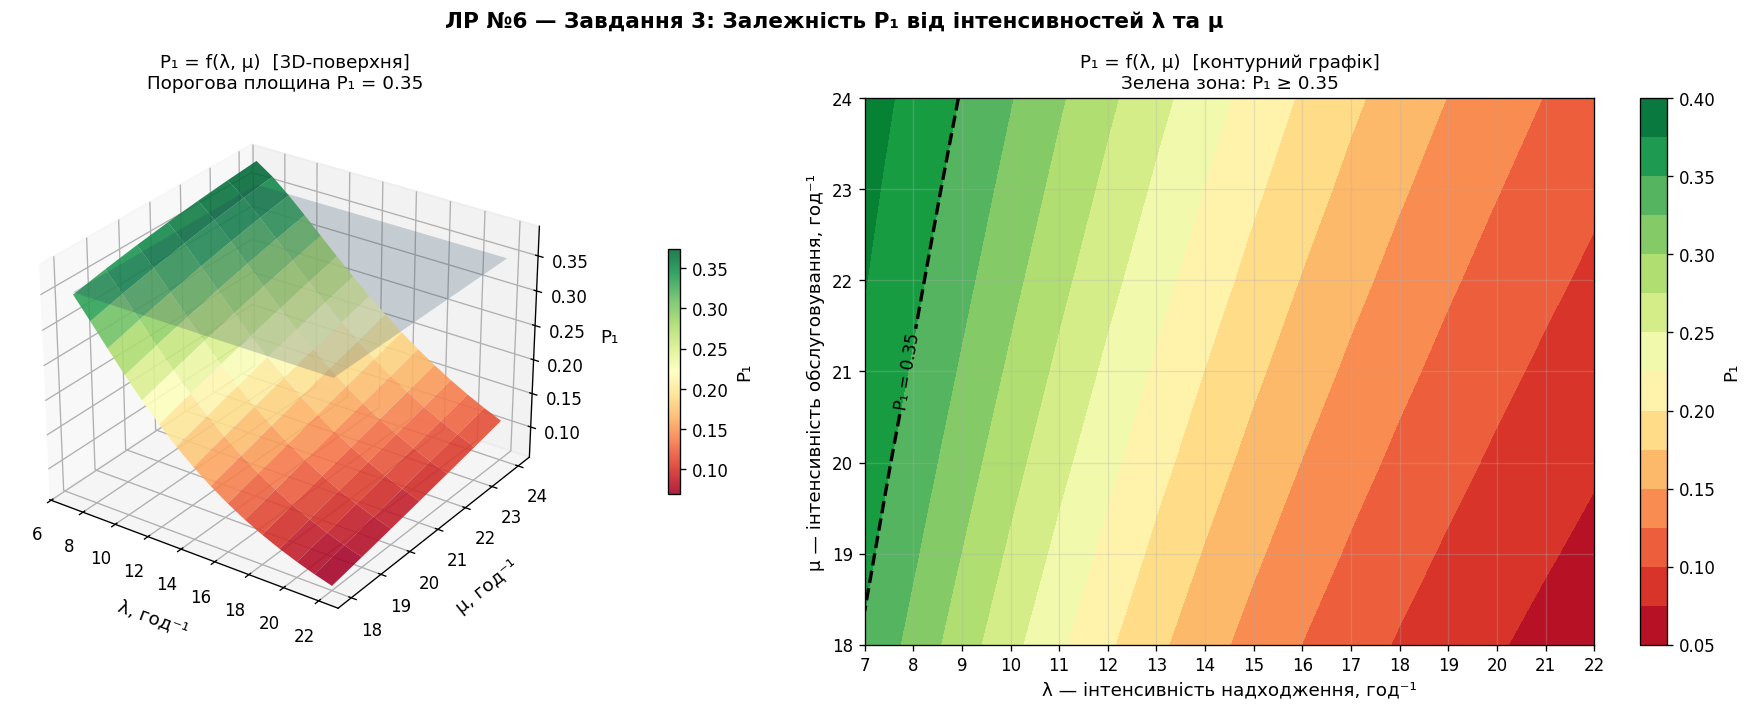

In [6]:
print("=" * 72)
print("  ЗАВДАННЯ 3: Графік P₁ = f(λ, μ)  (аналог рис. 6.5 методичних вк.)")
print("=" * 72)

fig = plt.figure(figsize=(16, 6))

# ── (A) 3D-поверхня ───────────────────────────────────────────────────────────
ax3d = fig.add_subplot(121, projection="3d")
surf = ax3d.plot_surface(
    LAM_grid, MU_grid, P1_grid,
    cmap=cm.RdYlGn, alpha=0.88,
    linewidth=0, antialiased=True,
)
# Площина порогу P₁ = 0.35
ax3d.plot_surface(
    LAM_grid, MU_grid,
    np.full_like(P1_grid, THRESHOLD),
    alpha=0.22, color="steelblue",
)
ax3d.set_title(f"P₁ = f(λ, μ)  [3D-поверхня]\nПорогова площина P₁ = {THRESHOLD}", fontsize=11)
ax3d.set_xlabel("λ, год⁻¹", labelpad=8)
ax3d.set_ylabel("μ, год⁻¹", labelpad=8)
ax3d.set_zlabel("P₁", labelpad=6)
ax3d.view_init(elev=28, azim=-55)
fig.colorbar(surf, ax=ax3d, shrink=0.45, pad=0.12, label="P₁")

# ── (B) Контурний графік (аналог Excel-графіку з методичних вказівок) ────────
ax2d = fig.add_subplot(122)
levels = np.arange(0.05, 0.42, 0.025)
cf = ax2d.contourf(LAM_grid, MU_grid, P1_grid, levels=levels, cmap="RdYlGn")
cs = ax2d.contour(LAM_grid, MU_grid, P1_grid, levels=[THRESHOLD],
                  colors="black", linewidths=2.0, linestyles="--")
ax2d.clabel(cs, fmt=f"P₁ = {THRESHOLD}", fontsize=10, inline=True)

# Область де P₁ >= 0.35
ax2d.contourf(LAM_grid, MU_grid, P1_grid,
              levels=[THRESHOLD, P1_grid.max() + 0.1],
              colors=["#00aa00"], alpha=0.18)

fig.colorbar(cf, ax=ax2d, label="P₁")
ax2d.set_title(f"P₁ = f(λ, μ)  [контурний графік]\n"
               f"Зелена зона: P₁ ≥ {THRESHOLD}", fontsize=11)
ax2d.set_xlabel("λ — інтенсивність надходження, год⁻¹")
ax2d.set_ylabel("μ — інтенсивність обслуговування, год⁻¹")
ax2d.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax2d.yaxis.set_major_locator(mticker.MultipleLocator(1))
ax2d.grid(True, alpha=0.3)

plt.suptitle(
    "ЛР №6 — Завдання 3: Залежність P₁ від інтенсивностей λ та μ",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()

  ЗАВДАННЯ 3: Лінійні графіки P₁(μ) — аналог Excel-ліній на рис. 6.5


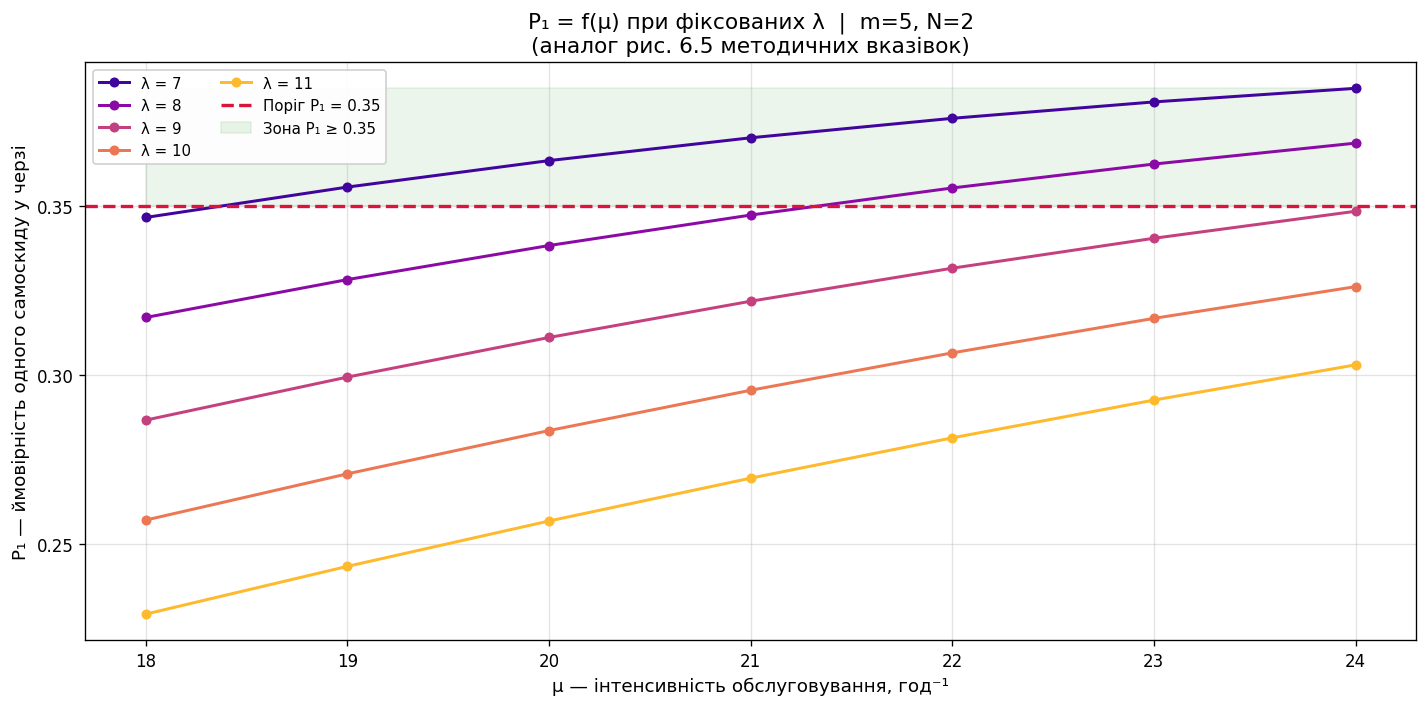

In [7]:
print("=" * 72)
print("  ЗАВДАННЯ 3: Лінійні графіки P₁(μ) — аналог Excel-ліній на рис. 6.5")
print("=" * 72)

# Вибираємо λ для яких є хоча б часткове перекриття з порогом 0.35
lam_plot_indices = [i for i, lam in enumerate(lam_list)
                    if any(P1_grid[i, j] >= THRESHOLD * 0.80
                           for j in range(len(mu_list)))]

palette_lines = plt.cm.plasma(np.linspace(0.1, 0.85, len(lam_plot_indices)))

fig, ax = plt.subplots(figsize=(12, 6))

for color, idx in zip(palette_lines, lam_plot_indices):
    lam_val = lam_list[idx]
    ax.plot(mu_list, P1_grid[idx, :], "o-", color=color,
            linewidth=1.8, markersize=5, label=f"λ = {lam_val}")

# Горизонтальна лінія порогу
ax.axhline(THRESHOLD, color="crimson", linestyle="--", linewidth=2.0,
           label=f"Поріг P₁ = {THRESHOLD}")

# Виділення зони вище порогу
ax.fill_between(mu_list,
                THRESHOLD, max(P1_grid.max(), THRESHOLD + 0.02),
                alpha=0.08, color="green", label="Зона P₁ ≥ 0.35")

ax.set_title(
    f"P₁ = f(μ) при фіксованих λ  |  m={M_TRUCKS}, N={N_EXCAV}\n"
    f"(аналог рис. 6.5 методичних вказівок)",
    fontsize=13
)
ax.set_xlabel("μ — інтенсивність обслуговування, год⁻¹")
ax.set_ylabel("P₁ — ймовірність одного самоскиду у черзі")
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.05))
ax.legend(loc="upper left", ncol=2, framealpha=0.9)
ax.grid(True)

plt.tight_layout()
plt.show()